In [1]:
!pip install sentence-transformers


In [2]:
sentences = [
    # Cricket (3)
    "The spinner deceived the batsman with a sharp turning delivery",
    "Under pressure, the captain rotated the bowlers strategically",
    "A last over boundary sealed the victory for the chasing team",

    # Cooking (3)
    "The chef caramelized onions slowly to enhance the flavor",
    "A pinch of cinnamon completely changed the taste of the dish",
    "Let the dough rest so the bread becomes soft and airy",

    # Cybersecurity (4)
    "Multi-factor authentication adds an extra layer of account security",
    "Hackers often exploit weak network configurations to gain access",
    "Regular software updates help prevent security vulnerabilities",
    "Encrypted communication keeps sensitive information safe from attackers"
]


In [4]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print(embeddings.shape)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


(10, 384)


In [5]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)


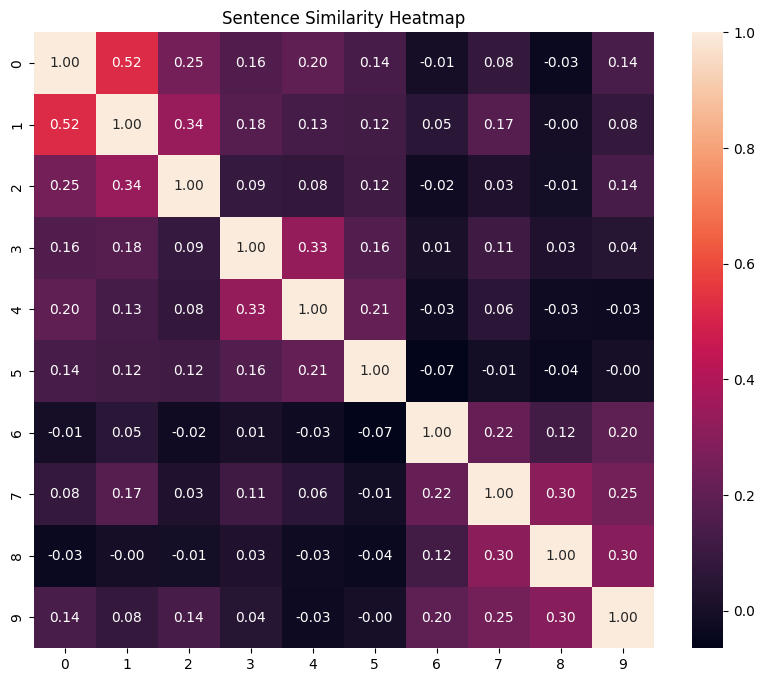

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f")
plt.title("Sentence Similarity Heatmap")
plt.show()

In [7]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]


In [8]:
import numpy as np

top_2_idx = np.argsort(similarities)[-2:][::-1]

for i in top_2_idx:
    print("Sentence:", sentences[i])
    print("Similarity Score:", similarities[i])
    print()


Sentence: Under pressure, the captain rotated the bowlers strategically
Similarity Score: 0.57279134

Sentence: The spinner deceived the batsman with a sharp turning delivery
Similarity Score: 0.5090648

